<a href="https://colab.research.google.com/github/Nicolsag/Classifica-o-de-Diabetes/blob/main/Modelo_de_Classifica%C3%A7%C3%A3o_para_Diagn%C3%B3stico_de_Diabetes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Conjunto de dados de indicadores de saúde para diabetes**
<br>


##Objetivo:
<br>
Criar um modelo de Machine Learning capaz de identificar casos de diabetes, focando em melhorar seu desempenho com técnicas de tratamento de dados, escolha das variáveis mais importantes e ajustes nos parâmetros, avaliando os resultados com métricas adequadas.
<br>


<br>

## Tecnologias usadas:

<br>

* Python: Linguagem de programação base;

* NumPy: Responsável pela computação numérica e manipulação de tensores e arrays multidimensionais. É o motor de execução utilizado internamente pelo Scikit-learn e XGBoost para realizar os cálculos matemáticos dos algoritmos;

* Pandas: Utilizada para a ingestão, limpeza e estruturação dos dados em DataFrames. É a ferramenta que permite o particionamento dos dados e a organização tabular necessária antes da entrada no pipeline de pré-processamento;

* Scikit-learn: Biblioteca para modelagem preditiva, métricas de avaliação (Recall, ROC-AUC, Confusion Matrix) e transformações de dados;

* XGBoost: Algoritmo de Gradient Boosting otimizado para eficiência computacional;

* LightGBM: Framework de Gradient Boosting baseado em árvores de decisão, focado em performance e memória;

* Imbalanced-learn: Utilização de ImbPipeline e SMOTE-NC para balanceamento sintético de classes com dados mistos (numéricos e categóricos);

* Matplotlib & Seaborn: Bibliotecas para visualização estatística e análise de performance dos modelos;

* Optuna: Framework de otimização de hiperparâmetros via Busca Bayesiana (Tree-structured Parzen Estimator);

* Joblib: Ferramenta para a serialização e persistência de modelos de Machine Learning, otimizada para manipular grandes arrays NumPy e exportar o classificador para uso em predições futuras.

----------------------------------------------------------

##Para este projeto, usaremos o seguinte dataset:
https://www.kaggle.com/datasets/alexteboul/diabetes-health-indicators-dataset
<br>



Informações do Dataset:
<br>


> "O Behavioral Risk Factor Surveillance System (BRFSS) é uma pesquisa telefônica relacionada à saúde que é coletada anualmente pelo CDC. A cada ano, a pesquisa coleta respostas de mais de 400.000 americanos sobre comportamentos de risco relacionados à saúde, condições crônicas de saúde e o uso de serviços preventivos. É realizada todos os anos desde 1984. Para este projeto, foi utilizado um csv do conjunto de dados disponível no Kaggle para o ano de 2015. Este conjunto de dados original contém respostas de 441.455 indivíduos e tem 330 recursos. Esses recursos são perguntas feitas diretamente aos participantes ou variáveis calculadas com base nas respostas individuais dos participantes."

## Descrição das Variáveis:

| Feature | Descrição |
|--------|----------|
| Diabetes_012 |  0 = Sem Diabetes, 1 = Pre Diabetes, 2 = Tem Diabetes|
| HighBP | Pressão alta |
| HighChol | Colesterol alto |
| CholCheck | Fez exame de colesterol nos últimos 5 anos |
| BMI | Índice de Massa Corporal |
| Smoker | Fumou ≥100 cigarros na vida |
| Stroke | Já teve AVC |
| HeartDiseaseorAttack | Doença cardíaca ou infarto |
| PhysActivity | Atividade física nos últimos 30 dias |
| Fruits | Consome frutas ≥1x/dia |
| Veggies | Consome vegetais ≥1x/dia |
| HvyAlcoholConsump | Consumo elevado de álcool |
| AnyHealthcare | Possui acesso a plano de saúde |
| NoDocbcCost | Não foi ao médico por custo |
| GenHlth | Saúde geral (1–5) |
| MentHlth | Dias com saúde mental ruim (0–30) |
| PhysHlth | Dias com saúde física ruim (0–30) |
| DiffWalk | Dificuldade para andar/subir escadas |
| Sex | Sexo: 0 = Feminino, 1 = Masculino |
| Age | Faixa etária (1–13) |
| Education | Nível educacional (1–6) |
| Income | Nível de renda (1–8) |

<br>

-------------------------------------------------------

###Para começar, importaremos as bibliotecas que usaremos para importação e tratamento de dados e o Dataset:

In [ ]:
from google.colab import drive
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from warnings import filterwarnings

In [ ]:
# Esta função é utilizada para suprimir a exibição de avisos (warnings) durante a execução de códigos.

filterwarnings('ignore')

In [ ]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/datasets for training/diabetes_012_health_indicators_BRFSS2015.csv') ## <- caminho

--------------------------------------------------------------------------------

<br>

###Fazendo a pré visualização dos dados para checar se os dados foram inseridos corretamente:

<br>

In [ ]:
df

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
253675,0.0,1.0,1.0,1.0,45.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,5.0,0.0,1.0,5.0,6.0,7.0
253676,2.0,1.0,1.0,1.0,18.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,4.0,0.0,0.0,1.0,0.0,11.0,2.0,4.0
253677,0.0,0.0,0.0,1.0,28.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,2.0,5.0,2.0
253678,0.0,1.0,0.0,1.0,23.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,0.0,0.0,1.0,7.0,5.0,1.0


<br>

###Aqui estamos checando informações que serão importantes para um prévio tratamento de dados, como:

<br>

O método `df.info()` fornece um resumo técnico e conciso do DataFrame, detalhando os seguintes pontos:

<br>

* Resumo do Índice: Exibe o tipo de índice e o número total de entradas (linhas);

* Colunas: Lista o nome de todas as colunas presentes no conjunto de dados;

* Valores Não Nulos (Non-Null Count): Indica a quantidade de registros preenchidos, facilitando a identificação de dados ausentes;

* Tipos de Dados (Dtype): Especifica o formato de cada coluna (ex: `int64` para inteiros, `float64` para decimais, object para `strings`/categorias e `bool` para booleanos);

* Uso de Memória: Informa o consumo de memória RAM do objeto no sistema.

<br>

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_012          253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  

--------------------------------------------------------------------------------

## Comparação de Distribuição: Tratamento de *Outliers:*

<br>

#### Este conjunto de gráficos ilustra o processo de saneamento e análise visual dos dados de IMC *(BMI):*

<br>

* Filtragem de Dados: O código remove registros com valores de IMC iguais ou superiores a 80, eliminando possíveis erros de digitação ou casos extremos que distorcem a escala estatística.

<br>


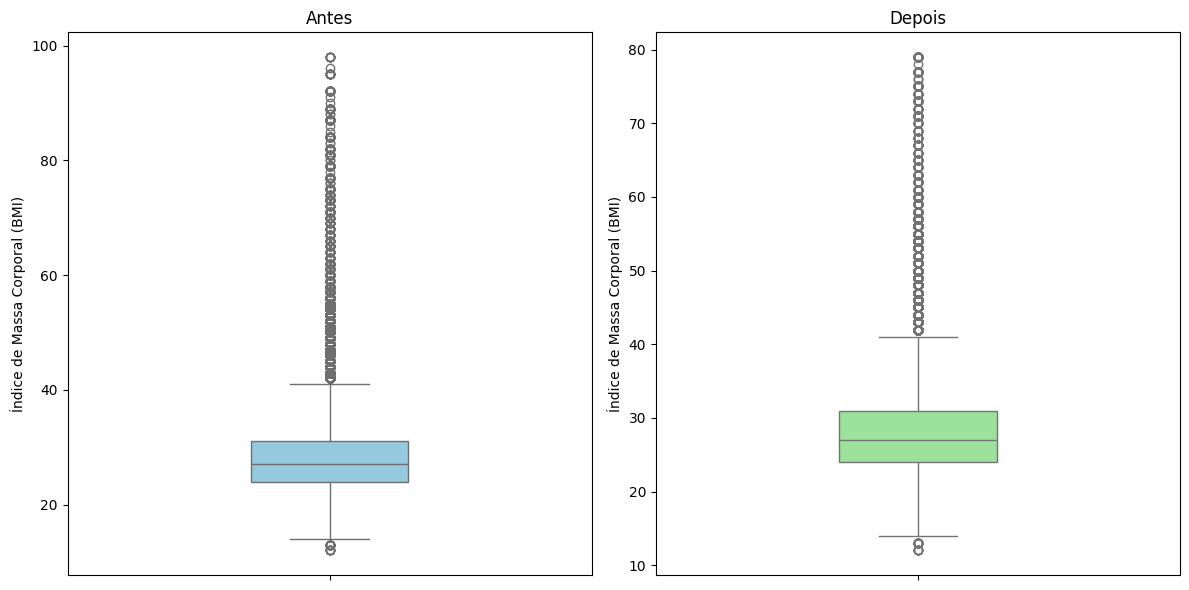

In [ ]:
# 1. Filtrando os dados
df_clean = df[df['BMI'] < 80]

# 2. Criando a figura com dois subplots (lado a lado)
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Gráfico Antes
sns.boxplot(y=df['BMI'], color='skyblue', width=0.3, ax=axes[0])
axes[0].set_title('Antes')
axes[0].set_ylabel('Índice de Massa Corporal (BMI)')

# Gráfico Depois
sns.boxplot(y=df_clean['BMI'], color='lightgreen', width=0.3, ax=axes[1])
axes[1].set_title('Depois')
axes[1].set_ylabel('Índice de Massa Corporal (BMI)')

plt.tight_layout()
plt.show()

#### Interpretação do *Boxplot:*

<br>

* Antes: Exibe a distribuição original onde valores muito altos *(outliers)* comprimem a visualização da "caixa" principal, dificultando a leitura da mediana e dos quartis.

* Depois: Após a limpeza, a escala se ajusta automaticamente, permitindo observar com clareza a dispersão e a concentração da maioria dos dados.

<br>

Objetivo: Facilitar a interpretação estatística e garantir que modelos de análise futuros não sejam enviesados por dados atípicos, proporcionando uma visão mais fiel à realidade do dataset.

<br>

<br>

#### Fazendo a remoção de linhas duplicadas:

<br>

In [ ]:
duplicidade = df_clean.duplicated().sum()

if duplicidade == 0:
  print("Não há linhas duplicadas.")
else:
    df_clean.drop_duplicates(inplace=True)
    print(f'{duplicidade} Linhas duplicadas removidas. ')

23899 Linhas duplicadas removidas. 


<br>

#### Fazendo a remoção de valores nulos:

<br>

In [ ]:
valores_nulos = df_clean.isnull().sum()

if valores_nulos.sum() == 0:
    print(f'Não há valores nulos no dataset.')
else:
    print(f'{valores_nulos.sum()} Valores nulos removidos.')
    df_clean.dropna(inplace=True)

Não há valores nulos no dataset.


<br>

#### Transformação da variável *`Diabetes_012`* em *`Diabetes_Binary`* :

A variável original *Diabetes-012*, que possui múltiplas classes, foi convertida para um formato binário (Diabetes_Binary). Essa transformação tem como objetivo simplificar o problema, tornando a tarefa de classificação mais direta e potencialmente melhorando o desempenho do modelo.

<br>

#### Agora, ao invés dos valores:
* 0 = Sem Diabetes;
* 1 = Pré Diabetes;
* 2 = Tem Diabetes.

<br>

#### O modelo adquiriu:
* 0 = Sem Diabetes;
* 1 = Pré Diabetes/Tem Diabetes.

<br>

In [ ]:
df_clean['Diabetes_Binary'] = df_clean['Diabetes_012'].replace({0: 0, 1: 1, 2: 1})
df_clean = df_clean.drop('Diabetes_012', axis=1)

<br>

#### Padronização de Colunas:

<br>

Aqui também iremos padronizar o resto das Colunas do Dataset em *`int8`* (Binário), ao invés de *`float64`*, para a melhor compreensão do modelo.

In [ ]:
for col in df_clean.columns:
    df_clean[col] = df_clean[col].astype('int8')

print(f"Dataset limpo e binarizado! Total de linhas úteis: {len(df_clean)}")

Dataset limpo e binarizado! Total de linhas úteis: 229500


<br>

#### Checando se tudo foi feito corretamente:

<br>

In [ ]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 229500 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype
---  ------                --------------   -----
 0   HighBP                229500 non-null  int8 
 1   HighChol              229500 non-null  int8 
 2   CholCheck             229500 non-null  int8 
 3   BMI                   229500 non-null  int8 
 4   Smoker                229500 non-null  int8 
 5   Stroke                229500 non-null  int8 
 6   HeartDiseaseorAttack  229500 non-null  int8 
 7   PhysActivity          229500 non-null  int8 
 8   Fruits                229500 non-null  int8 
 9   Veggies               229500 non-null  int8 
 10  HvyAlcoholConsump     229500 non-null  int8 
 11  AnyHealthcare         229500 non-null  int8 
 12  NoDocbcCost           229500 non-null  int8 
 13  GenHlth               229500 non-null  int8 
 14  MentHlth              229500 non-null  int8 
 15  PhysHlth              229500 non-null  

------------------------------------------------------------------------------

<br>

#### Análise de correlação entre as variáveis:

<br>

Foi realizada uma análise de correlação para identificar a relação entre as variáveis do conjunto de dados. Essa etapa auxilia na compreensão de quais atributos possuem maior influência sobre a variável alvo, além de apoiar decisões como seleção de features e possíveis ajustes no modelo.

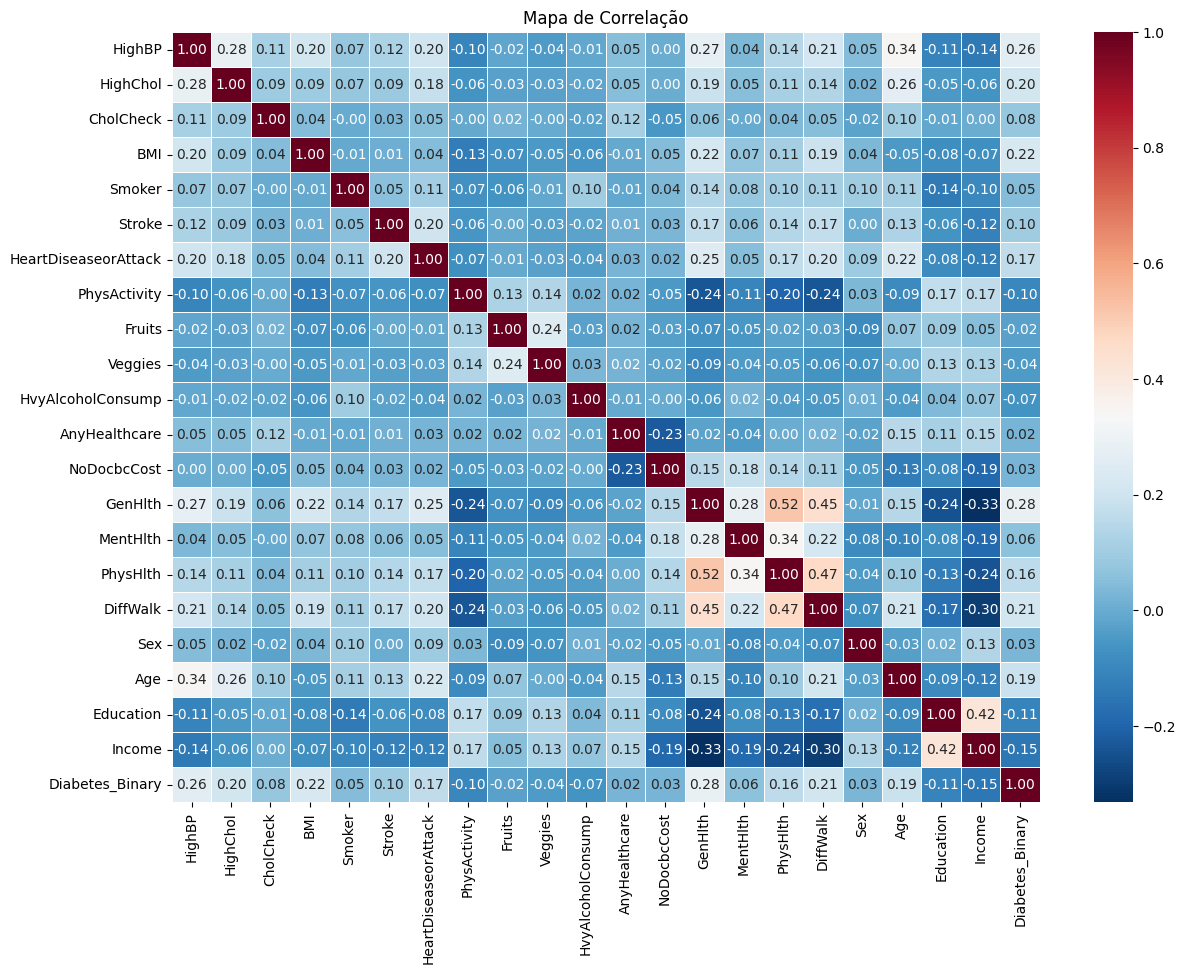

In [ ]:
corr = df_clean.corr(numeric_only=True)

plt.figure(figsize=(14, 10))
sns.heatmap(
    corr,
    annot=True,       # mostra os valores
    fmt=".2f",        # 2 casas decimais
    cmap="RdBu_r",      # cores
    linewidths=0.5
)

plt.title("Mapa de Correlação")
plt.show()

---------------------------

<br>

#### Aqui importaremos as bibliotecas responsáveis para essa etapa de treino e resultados do modelo:
<br>

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from imblearn.over_sampling import SMOTENC
from imblearn.pipeline import Pipeline as ImbPipeline

<br>

####Separação de Variáveis *(Features e Target):*

<br>

Aqui dividimos o que o modelo vai "estudar" do que ele deve "responder":

* `X` (Características): Coleta todas as informações dos pacientes (como IMC, idade e hábitos), removendo apenas a resposta final. São as pistas que o modelo usará para aprender.

* `y` (Alvo): Isola apenas a coluna `Diabetes_Binary`. É a variável alvo que o modelo irá aprender a prever a partir dos dados disponíveis.
<br>

Basicamente, estamos definindo: X são os dados de entrada e y é o que queremos descobrir.

In [ ]:
X = df_clean.drop('Diabetes_Binary', axis=1)
y = df_clean['Diabetes_Binary']

<br>

#### Divisão e Preparação dos Dados:

<br>

#### Este bloco prepara os dados para o modelo em três etapas para garantir uma avaliação imparcial:

<br>


* Treino (60%): Base de conhecimento para o modelo aprender os padrões de diabetes.

* Validação (20%): Conjunto para testar diferentes configurações do modelo e evitar o overfitting.

* Teste (20%): Dados nunca vistos, usados apenas para o resultado final do projeto.

<br>

####OBS:

* Estratificação (`stratify=y`): Garante que a proporção de positivos e negativos para diabetes seja a mesma no treino, validação e teste.

* Reprodutibilidade (`random_state=42`): Garante que a divisão dos dados seja idêntica toda vez que o notebook for executado.


In [ ]:
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Dos 80% restantes, separa 25% para VALIDAÇÃO (20% do total)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, stratify=y_temp, random_state=42
)

print(f"Treino: {len(X_train)} | Validação: {len(X_val)} | Teste: {len(X_test)}")

Treino: 137700 | Validação: 45900 | Teste: 45900


<br>

#### Construção do Pipeline e Treino:

<br>

Este bloco organiza o tratamento dos dados e o aprendizado do modelo em uma única linha de montagem:

* Equilíbrio (`SMOTENC`): Como geralmente há menos casos de diabetes no * dataset, ele cria exemplos sintéticos para o modelo aprender a identificar a doença de verdade, em vez de apenas "chutar" o resultado mais frequente.

* Modelo: `Random Forest` Entra como o nosso primeiro teste de estresse. A ideia aqui é ver se o dataset "conversa entre si" e validar a consistência dos dados antes de avançarmos para modelos ou otimizações mais complexas.

* Pipeline: Amarra todas essas etapas em um fluxo único, garantindo que o processo seja organizado e que não haja vazamento de informações entre o treino e o teste.

In [ ]:
colunas_continuas = ['BMI', 'PhysHlth', 'MentHlth']
colunas_categoricas = [col for col in X_train.columns if col not in colunas_continuas]
cat_indices = [X_train.columns.get_loc(col) for col in colunas_categoricas]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), colunas_continuas),
        ('cat', 'passthrough', colunas_categoricas)
    ])


smote_nc = SMOTENC(categorical_features=cat_indices, random_state=42)

modelo = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)

pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote_nc', smote_nc),
    ('classifier', modelo)
])

pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['BMI', 'PhysHlth',
                                                   'MentHlth']),
                                                 ('cat', 'passthrough',
                                                  ['HighBP', 'HighChol',
                                                   'CholCheck', 'Smoker',
                                                   'Stroke',
                                                   'HeartDiseaseorAttack',
                                                   'PhysActivity', 'Fruits',
                                                   'Veggies',
                                                   'HvyAlcoholConsump',
                                                   'AnyHealthcare',
                                                   'NoDocbcCost', 'GenHlth',
                                                   'DiffWalk', 'Sex', 'Age',
                                                   'Education', 'Income'])])),
                ('smote_nc',
                 SMOTENC(categorical_features=[0, 1, 2, 4, 5, 6, 7, 8, 9, 10,
                                               11, 12, 13, 16, 17, 18, 19, 20],
                         random_state=42)),
                ('classifier',
                 RandomForestClassifier(max_depth=15, n_jobs=-1,
                                        random_state=42))])

<br>

#### Conferência de Balanceamento:

<br>

Geramos gráficos comparando o "antes e depois" para validar se o `SMOTENC` realmente equilibrou as classes. Essa checagem visual é o que nos dá segurança de que o dataset está pronto para os primeiros testes, garantindo que o modelo não seja induzido ao erro pelo desequilíbrio original.

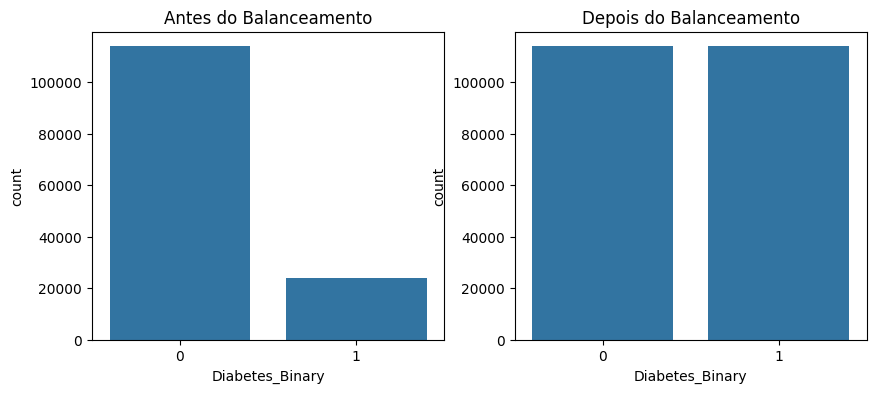

Original: [113892  23808] | Balanceado: [113892 113892]


In [ ]:
X_res, y_res = smote_nc.fit_resample(preprocessor.fit_transform(X_train), y_train)

# Exibição dos gráficos de balanceamento de classes
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
sns.countplot(x=y_train).set_title('Antes do Balanceamento')

plt.subplot(1, 2, 2)
sns.countplot(x=y_res).set_title('Depois do Balanceamento')

plt.show()

# Valores dos gráficos
print(f"Original: {np.bincount(y_train)} | Balanceado: {np.bincount(y_res)}")


<br>

#### Validação do Modelo:

<br>

Nesta etapa, verificamos se o nosso primeiro teste com `RandomForest` trouxe resultados consistentes.

<br>


---  TREINAMENTO DO MODELO ---

---  AVALIAÇÃO NA VALIDAÇÃO ---
              precision    recall  f1-score   support

           0       0.91      0.76      0.83     37964
           1       0.35      0.62      0.45      7936

    accuracy                           0.74     45900
   macro avg       0.63      0.69      0.64     45900
weighted avg       0.81      0.74      0.76     45900

ROC AUC (Validação): 0.7792

---  AVALIAÇÃO FINAL NO TESTE ---
Relatório de Classificação Final (Dados Inéditos):
              precision    recall  f1-score   support

           0       0.91      0.76      0.83     37964
           1       0.36      0.63      0.46      7936

    accuracy                           0.74     45900
   macro avg       0.63      0.70      0.64     45900
weighted avg       0.81      0.74      0.76     45900

ROC AUC (Teste): 0.7808


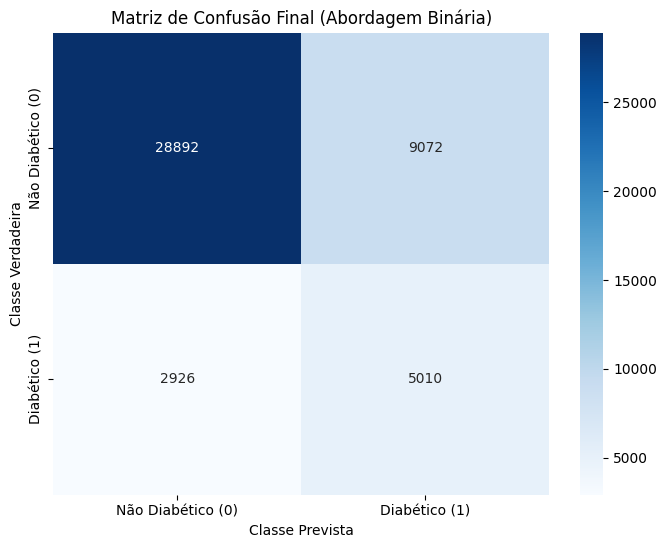

In [ ]:
print("\n---  TREINAMENTO DO MODELO ---")
pipeline.fit(X_train, y_train)

print("\n---  AVALIAÇÃO NA VALIDAÇÃO ---")
y_pred_val = pipeline.predict(X_val)
y_proba_val = pipeline.predict_proba(X_val)[:, 1] # Probabilidade apenas da classe 1 (Diabetes)

print(classification_report(y_val, y_pred_val))
auc_val = roc_auc_score(y_val, y_proba_val)
print(f"ROC AUC (Validação): {auc_val:.4f}")

print("\n---  AVALIAÇÃO FINAL NO TESTE ---")
y_pred_test = pipeline.predict(X_test)
y_proba_test = pipeline.predict_proba(X_test)[:, 1]

print("Relatório de Classificação Final (Dados Inéditos):")
print(classification_report(y_test, y_pred_test))
auc_test = roc_auc_score(y_test, y_proba_test)
print(f"ROC AUC (Teste): {auc_test:.4f}")


cm = confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Não Diabético (0)', 'Diabético (1)'],
            yticklabels=['Não Diabético (0)', 'Diabético (1)'])
plt.title('Matriz de Confusão Final (Abordagem Binária)')
plt.ylabel('Classe Verdadeira')
plt.xlabel('Classe Prevista')
plt.show()

* Consistência (ROC AUC): O valor de 0.77 tanto na validação quanto no teste é um excelente sinal. Isso mostra que o modelo não está "decorando" os dados (overfitting) e mantém a mesma qualidade com informações inéditas.

* Poder de Detecção (Recall da Classe 1): O modelo consegue identificar 63% dos casos reais de diabetes. Para um primeiro teste sem otimização pesada, isso indica que o dataset realmente "conversa" e as variáveis escolhidas têm poder preditivo.

* Ponto de Atenção (Precisão): A precisão de 0.36 na classe 1 mostra que ainda temos "alarmes falsos". Isso é esperado nesta fase inicial e nos dá uma direção clara para as próximas rodadas de ajustes;

* Veredito da Matriz: Conseguimos capturar 5.010 casos positivos de diabetes que seriam perdidos sem o modelo, validando que o caminho do balanceamento com SMOTENC funcionou.

<br>

#### Conclusão: O dataset passou no teste de estresse. Os números são sólidos o suficiente para seguirmos com a otimização dos hiperparâmetros ou testar algoritmos mais complexos

<br>

-----------------------------

<br>

#### Avaliação de Modelos e Otimização de Hiperparâmetros.


Nesta etapa, realizaremos a avaliação de diversos modelos com o objetivo de alcançar resultados superiores através do ajuste fino de hiperparâmetros.

<br>
<br>

Importação de Bibliotecas:

<br>

Para iniciar o processo, realizaremos a importação das bibliotecas que servirão como base para o desenvolvimento do projeto:

In [ ]:
import optuna
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import label_binarize
from sklearn.metrics import recall_score, roc_curve, auc

<br>

#### Otimização de Hiperparâmetros e Avaliação comparativa:

<br>

Esta seção implementa a busca bayesiana de hiperparâmetros utilizando a biblioteca `Optuna`, integrada a pipelines de tratamento de dados desbalanceados.

#### Definição da Função Objetivo (objective):

* A função consolida a lógica de otimização para múltiplos estimadores;

* Espaço de Busca: Define intervalos específicos para parâmetros críticos de modelos lineares (`C`), baseados em árvores (`Learning_rate`, `max_depth`, `n_estimators`) e baseados em instâncias (`n_neighbors`);

* Pipeline de Processamento: Integra o pré-processamento e o balanceamento de classes via `SMOTE-NC` dentro de um ImbPipeline, assegurando que a reamostragem ocorra estritamente nos dados de treino;

* Métrica de Performance: A função retorna o *Recall* (Sensibilidade) da classe minoritária, priorizando a redução de falsos negativos.

<br>

#### Ciclo de Otimização e Reconstrução:

* Estudo de Otimização: O `optuna.create_study` busca maximizar o *Recall* através de ensaios independentes para cada algoritmo listado em `modelos_alvo`;

* Persistência de Resultados: Os melhores parâmetros de cada estudo são extraídos para instanciar modelos finais, que são treinados no conjunto completo de treino e armazenados no dicionário `melhores_pipelines`.

In [ ]:
# Dicionário para salvar os resultados
melhores_pipelines = {}

def objective(trial, classifier_name):
    # Sujestão de Hiperparâmetros
    if classifier_name == "LogisticRegression":
        arg_c = trial.suggest_float("C", 1e-3, 10.0, log=True)
        model = LogisticRegression(C=arg_c, class_weight='balanced', random_state=42, solver='liblinear')

    elif classifier_name == "XGBClassifier":
        arg_max_depth = trial.suggest_int("max_depth", 3, 10)
        arg_lr = trial.suggest_float("learning_rate", 0.01, 0.3)
        model = XGBClassifier(max_depth=arg_max_depth, learning_rate=arg_lr, random_state=42, eval_metric='logloss')

    elif classifier_name == "LGBMClassifier":
        arg_leaves = trial.suggest_int("num_leaves", 20, 80)
        arg_max_depth = trial.suggest_int("max_depth", 3, 10)
        arg_lr = trial.suggest_float("learning_rate", 0.01, 0.3)
        model = LGBMClassifier(num_leaves=arg_leaves, max_depth=arg_max_depth, learning_rate=arg_lr,
                               class_weight='balanced', random_state=42, verbosity=-1)

    elif classifier_name == "KNeighborsClassifier":
        arg_neighbors = trial.suggest_int("n_neighbors", 3, 15)
        arg_weights = trial.suggest_categorical("weights", ["uniform", "distance"])
        model = KNeighborsClassifier(n_neighbors=arg_neighbors, weights=arg_weights)

    elif classifier_name == "RandomForestClassifier":
        arg_n = trial.suggest_int('n_estimators', 50, 300)
        arg_d = trial.suggest_int('max_depth', 5, 25)
        model = RandomForestClassifier(n_estimators=arg_n, max_depth=arg_d, random_state=42, n_jobs=-1)

    # 3. Pipeline com seus componentes
    pipeline_trial = ImbPipeline(steps=[
        ('preprocessor', preprocessor),
        ('smote_nc', smote_nc),
        ('classifier', model)
    ])

    # 4. Treino e avaliação (Usando Validação para otimizar)
    pipeline_trial.fit(X_train, y_train)
    y_pred_val = pipeline_trial.predict(X_val)

    return recall_score(y_val, y_pred_val, pos_label=1)


# --- LOOP DE OTIMIZAÇÃO ---
modelos_alvo = ["LogisticRegression", "XGBClassifier", "LGBMClassifier", "KNeighborsClassifier", "RandomForestClassifier"]

for nome in modelos_alvo:
    print(f"\nIniciando Optuna para: {nome}")
    study = optuna.create_study(direction="maximize")
    study.optimize(lambda trial: objective(trial, nome), n_trials=10) # 10 trials para ser rápido

    # 5. Reconstruindo o melhor modelo
    params = study.best_params
    if nome == "LogisticRegression":
        final_m = LogisticRegression(**params, class_weight='balanced', random_state=42, solver='liblinear')
    elif nome == "XGBClassifier":
        final_m = XGBClassifier(**params, random_state=42, eval_metric='logloss')
    elif nome == "LGBMClassifier":
        final_m = LGBMClassifier(**params, class_weight='balanced', random_state=42, verbosity=-1)
    elif nome == "KNeighborsClassifier":
        final_m = KNeighborsClassifier(**params)
    elif nome == "RandomForestClassifier":
        final_m = RandomForestClassifier(**params, random_state=42, n_jobs=-1)

    best_pipe = ImbPipeline([
        ('preprocessor', preprocessor),
        ('smote_nc', smote_nc),
        ('classifier', final_m)
    ])

    best_pipe.fit(X_train, y_train)
    melhores_pipelines[nome] = best_pipe

<br>

#### Como o modelo já havia sido previamente treinado, optamos por armazenar o treino usando `Joblib`, com o objetivo de otimizar tempo.

<br>

importando a biblioteca:

In [ ]:
import joblib

<br>

#### Avaliação comparativa dos modelos, após a otimização de hiperparâmetros com foco em *Recall*, apresenta as seguintes conclusões técnicas:

<br>

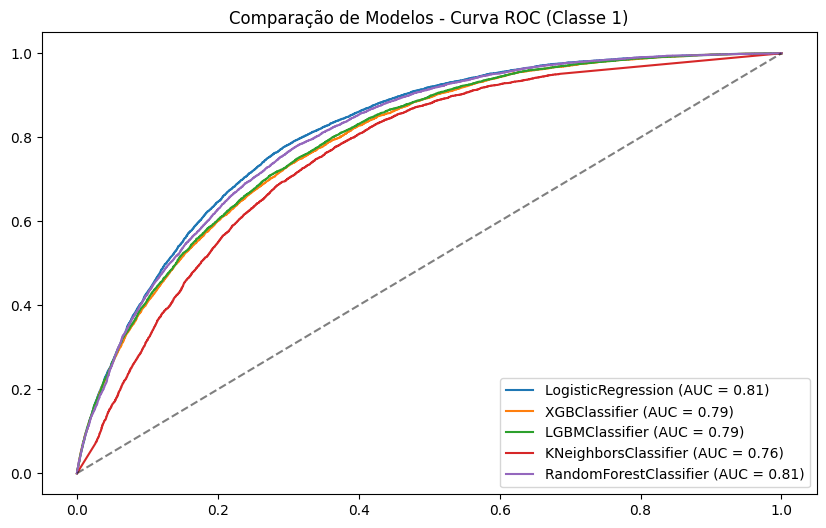

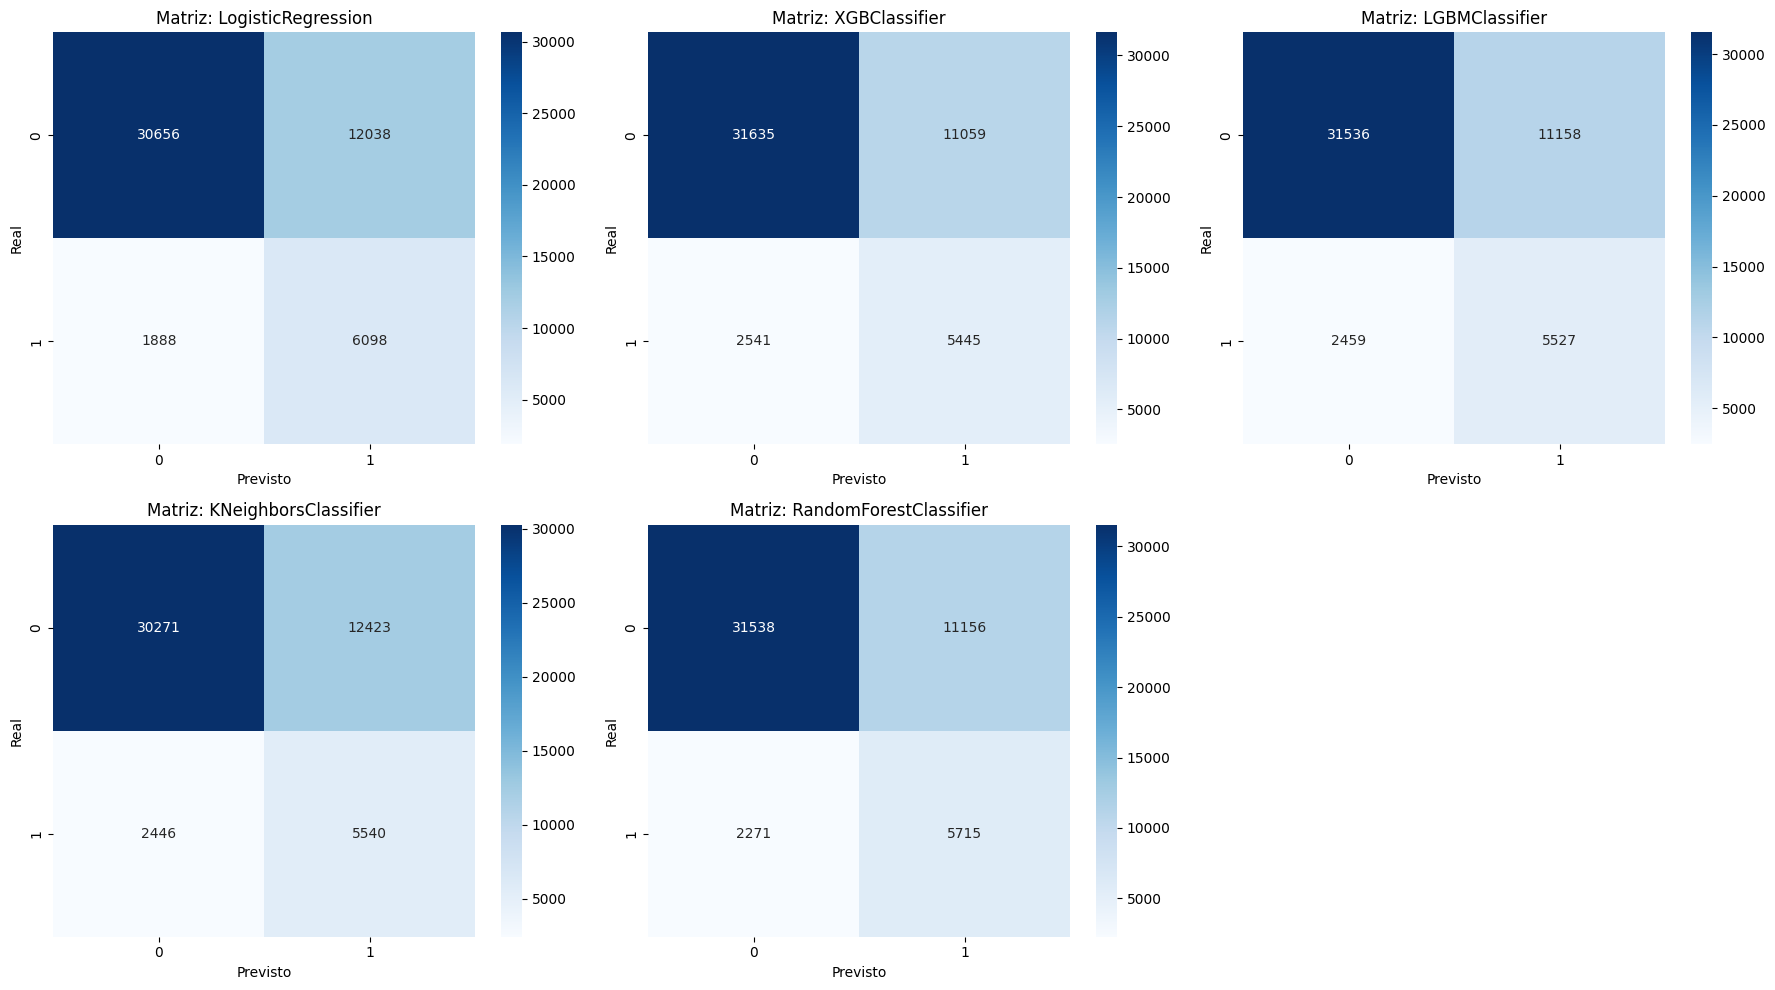

In [ ]:
# Carregar os arquivos
melhores_pipelines = joblib.load('/content/drive/MyDrive/datasets for training/Diabetes treino/meus_modelos_treinados.joblib')
X_test = joblib.load('/content/drive/MyDrive/datasets for training/Diabetes treino/X_test.joblib')
y_test = joblib.load('/content/drive/MyDrive/datasets for training/Diabetes treino/y_test.joblib')

# --- VISUALIZAÇÕES FINAIS ---

# Curva ROC Comparativa
plt.figure(figsize=(10, 6))
for nome, pipe in melhores_pipelines.items():
    y_score = pipe.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_score)
    plt.plot(fpr, tpr, label=f'{nome} (AUC = {auc(fpr, tpr):.2f})')

plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.title('Comparação de Modelos - Curva ROC (Classe 1)')
plt.legend()
plt.show()

# Matrizes de Confusão em Grade
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, (nome, pipe) in enumerate(melhores_pipelines.items()):
    y_pred = pipe.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i])
    axes[i].set_title(f'Matriz: {nome}')
    axes[i].set_xlabel('Previsto')
    axes[i].set_ylabel('Real')

fig.delaxes(axes[5]) # Remove o espaço vazio
plt.tight_layout()
plt.show()

<br>

* Desempenho Global (Curva ROC/AUC)
​Liderança Técnica: Os modelos `LogisticRegression` e `RandomForestClassifier` apresentaram o maior desempenho global, ambos com AUC de 0.81;

* ​Consistência: Os modelos de boosting (`XGBoost` e `LightGBM`) demonstraram resultados idênticos (AUC 0.79), sugerindo uma convergência de aprendizado para o espaço de características fornecido;

* ​Baseline Inferior: O `KNeighborsClassifier` obteve a menor área sob a curva (0.76), indicando menor capacidade de discriminação entre as classes em comparação aos demais estimadores;
​
<br>

#### Análise das Matrizes de Confusão (Foco em Recall):

<br>

​Dado que a função objetivo visava a maximização do Recall para a Classe 1:

* ​Melhor Sensibilidade: A `LogisticRegression` obteve o desempenho superior na identificação da classe positiva, apresentando o menor volume de Falsos Negativos (1.888).

* ​Trade-off de Precisão: Embora maximize o *Recall*, a regressão logística exibe um volume elevado de Falsos Positivos (12.038), reflexo do ajuste de `class_weight='balanced'`.

* Equilíbrio Estrutural: O `RandomForestClassifier` surge como a alternativa mais equilibrada, mantendo um *Recall* robusto (Falsos Negativos: 2.271) com uma eficiência ligeiramente superior na contenção de Falsos Positivos em relação à regressão Logística.

<br>

#### ​Conclusão Final:

<br>

​O modelo `LogisticRegression` é selecionado como o estimador final por atender rigorosamente ao critério de otimização definido (maior *Recall)*.

 Para cenários onde o custo do Falso Positivo seja crítico, o `RandomForestClassifier` recomenda-se como segunda opção viável devido à sua estabilidade métrica.